In [1]:
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np

In [2]:
sheet_id = "1VurJODWndk26VfyNd6IDgXsvX7uR1A_IxhTA4xcGRco"
sheet_gid = "0"  # zakładka o gid=0

url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={sheet_gid}"

full_df = pd.read_csv(url)

In [3]:
df = full_df.copy()
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
now = datetime.now()
start_of_month = datetime(now.year, now.month, 1)
df['Weight'] = df['Weight'].astype(str).str.replace(',', '.').str.strip()
df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce')
df = df[df['Date'] < start_of_month]


In [4]:
df.loc[[1019, 1020,1021,1132,1133,1134,1135]]

,Date,Weight
1019,2024-09-19,73.2
1020,2024-09-20,NaN
1021,2024-09-21,73.1
1132,2025-01-10,73.9
1133,2025-01-11,73.9
1134,2025-01-12,NaN
1135,2025-01-13,73.5


In [5]:
df['Weight'] = df['Weight'].interpolate(method='linear')

In [6]:
df.loc[[1019, 1020,1021,1132,1133,1134,1135]]

,Date,Weight
1019,2024-09-19,73.20
1020,2024-09-20,73.15
1021,2024-09-21,73.10
1132,2025-01-10,73.90
1133,2025-01-11,73.90
1134,2025-01-12,73.70
1135,2025-01-13,73.50


In [7]:
monthly_df = df.resample('ME', on='Date').mean().reset_index()

In [8]:
monthly_df.head()

,Date,Weight
0,2021-12-31,71.140741
1,2022-01-31,71.645161
2,2022-02-28,71.592857
3,2022-03-31,71.680645
4,2022-04-30,72.540000


In [9]:
print(monthly_df.head())
print(monthly_df.info())

        Date     Weight
0 2021-12-31  71.140741
1 2022-01-31  71.645161
2 2022-02-28  71.592857
3 2022-03-31  71.680645
4 2022-04-30  72.540000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    44 non-null     datetime64[ns]
 1   Weight  44 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 836.0 bytes
None


/tmp/ipykernel_9476/1497389523.py:6: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_df = monthly_df.resample('Q', on='Date').mean()


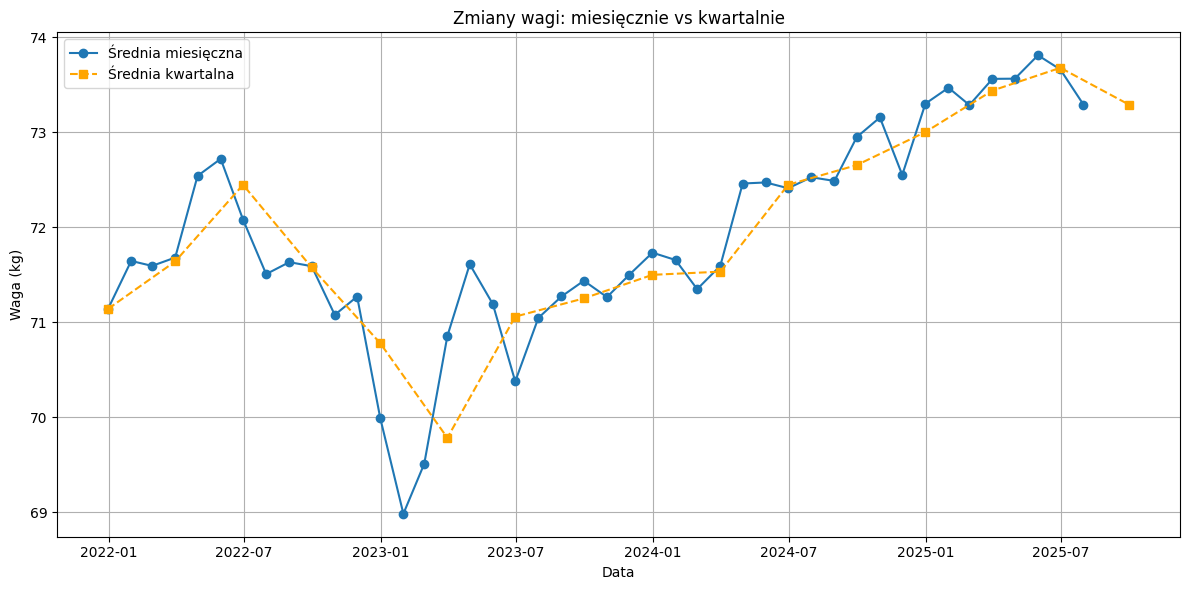

In [10]:

# Wykres miesięczny
plt.figure(figsize=(12, 6))
plt.plot(monthly_df['Date'], monthly_df['Weight'], marker='o', label='Średnia miesięczna')

# Wykres kwartalny (agregacja)
quarterly_df = monthly_df.resample('Q', on='Date').mean()

plt.plot(quarterly_df.index, quarterly_df['Weight'], marker='s', linestyle='--', color='orange', label='Średnia kwartalna')

# Stylizacja
plt.title('Zmiany wagi: miesięcznie vs kwartalnie')
plt.xlabel('Data')
plt.ylabel('Waga (kg)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


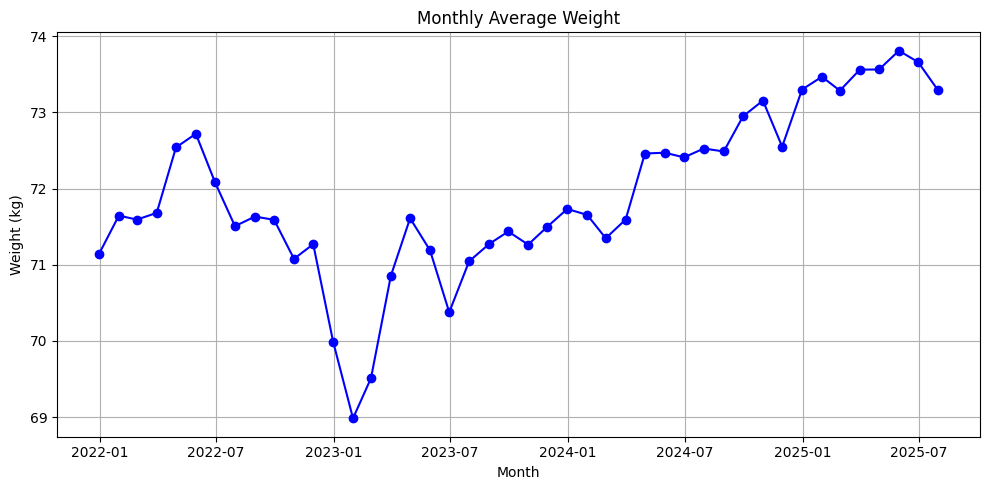

In [11]:
# Monthly weight plot
plt.figure(figsize=(10, 5))
plt.plot(monthly_df['Date'], monthly_df['Weight'], marker='o', linestyle='-', color='blue')
plt.title('Monthly Average Weight')
plt.xlabel('Month')
plt.ylabel('Weight (kg)')
plt.grid(True)
plt.tight_layout()
plt.show()


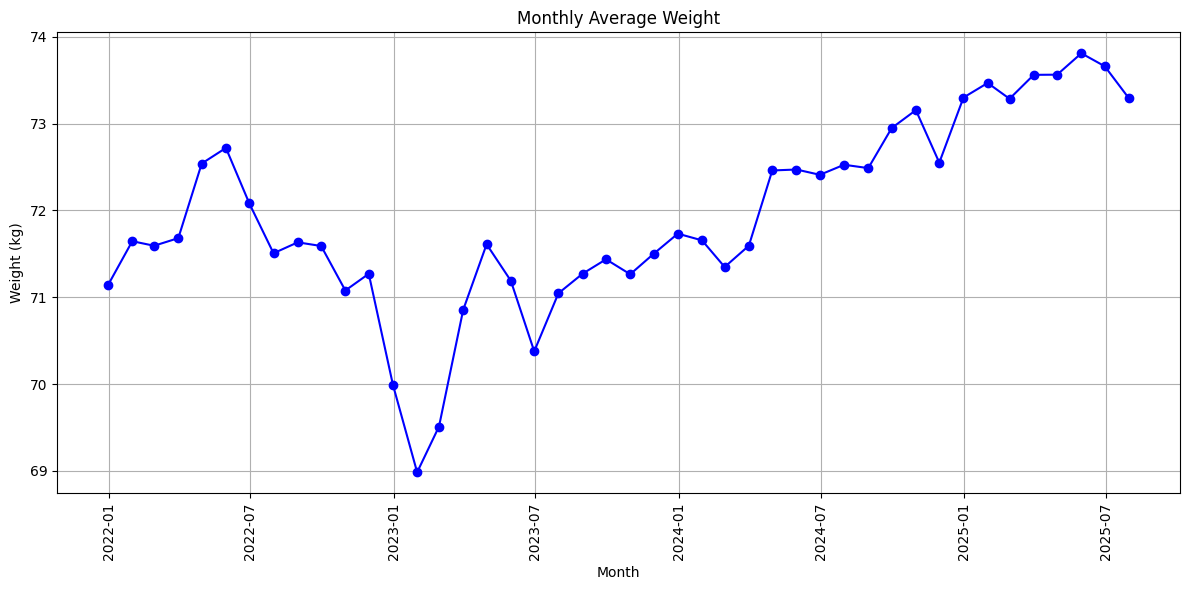

In [12]:
# Monthly weight plot with rotated x-axis labels
plt.figure(figsize=(12, 6))
plt.plot(monthly_df['Date'], monthly_df['Weight'], marker='o', linestyle='-', color='blue')
plt.title('Monthly Average Weight')
plt.xlabel('Month')
plt.ylabel('Weight (kg)')
plt.xticks(rotation=90)  # Rotate month labels
plt.grid(True)
plt.tight_layout()
plt.show()

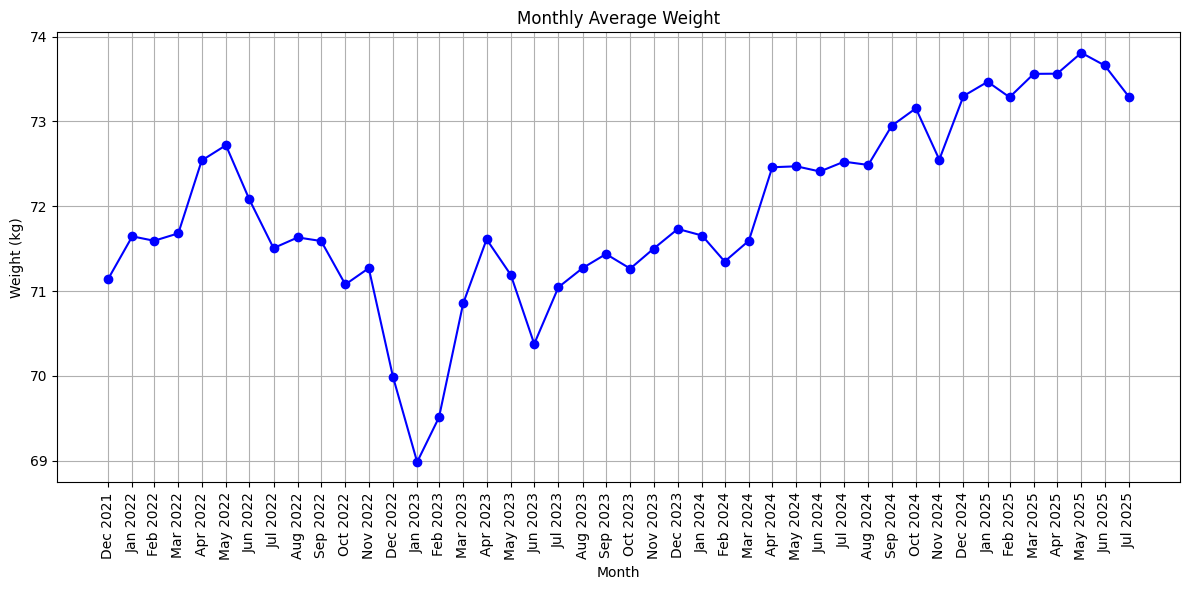

In [13]:
# Extract all dates from monthly_df
dates = monthly_df['Date']
weights = monthly_df['Weight']

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(dates, weights, marker='o', linestyle='-', color='blue')
plt.title('Monthly Average Weight')
plt.xlabel('Month')
plt.ylabel('Weight (kg)')

# Force all months to appear on x-axis
plt.xticks(ticks=dates, labels=[d.strftime('%b %Y') for d in dates], rotation=90)

plt.grid(True)
plt.tight_layout()
plt.show()

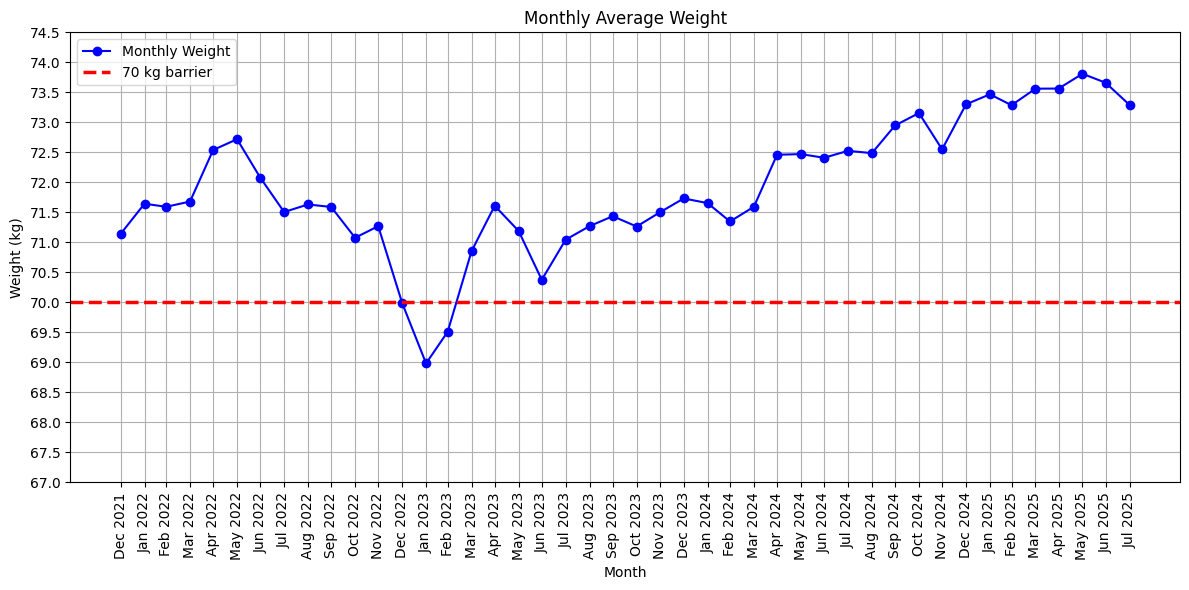

In [14]:
# Extract data
dates = monthly_df['Date']
weights = monthly_df['Weight']

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(dates, weights, marker='o', linestyle='-', color='blue', label='Monthly Weight')

# Set title and labels
plt.title('Monthly Average Weight')
plt.xlabel('Month')
plt.ylabel('Weight (kg)')

# Rotate x-axis labels
plt.xticks(ticks=dates, labels=[d.strftime('%b %Y') for d in dates], rotation=90)

# Set y-axis ticks in 0.5 kg steps
min_weight = weights.min()
max_weight = weights.max()
plt.yticks(np.arange(np.floor(min_weight) - 1, np.ceil(max_weight) + 1, 0.5))

# Add horizontal line at 70 kg
plt.axhline(y=70, color='red', linestyle='--', linewidth=2.5, label='70 kg barrier')

# Grid and legend
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


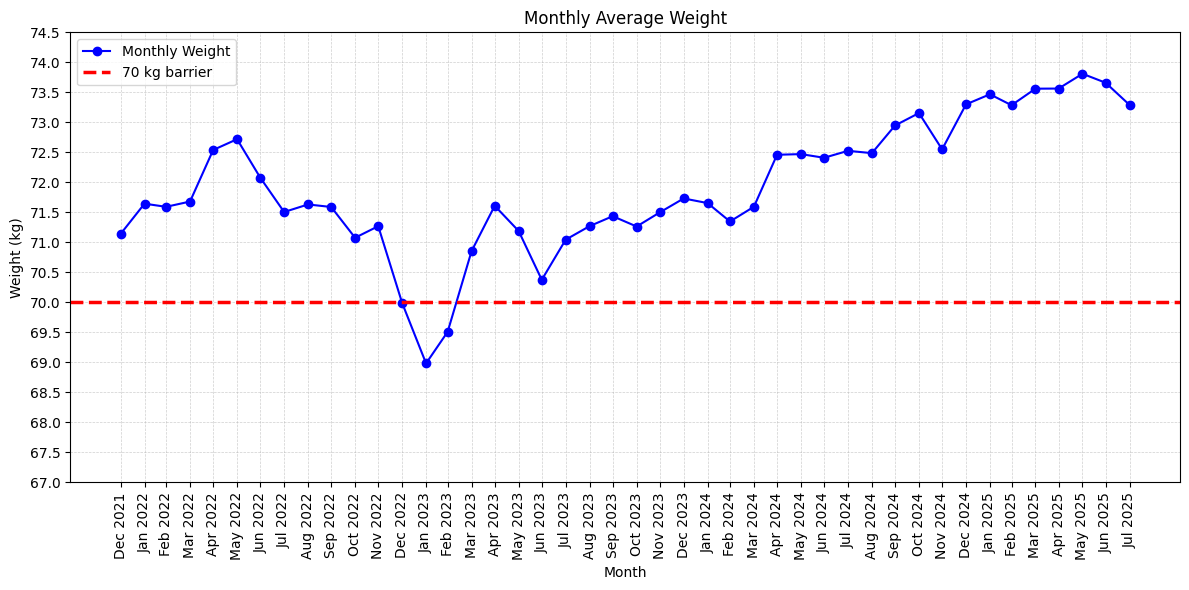

In [15]:
# Extract data
dates = monthly_df['Date']
weights = monthly_df['Weight']

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(dates, weights, marker='o', linestyle='-', color='blue', label='Monthly Weight')

# Title and labels
plt.title('Monthly Average Weight')
plt.xlabel('Month')
plt.ylabel('Weight (kg)')

# Rotate x-axis labels and show all months
plt.xticks(ticks=dates, labels=[d.strftime('%b %Y') for d in dates], rotation=90)

# Set y-axis ticks in 0.5 kg steps
min_weight = weights.min()
max_weight = weights.max()
plt.yticks(np.arange(np.floor(min_weight) - 1, np.ceil(max_weight) + 1, 0.5))

# Add bold horizontal line at 70 kg
plt.axhline(y=70, color='red', linestyle='--', linewidth=2.5, label='70 kg barrier')

# Subtle grid
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)

# Legend and layout
plt.legend()
plt.tight_layout()
plt.show()


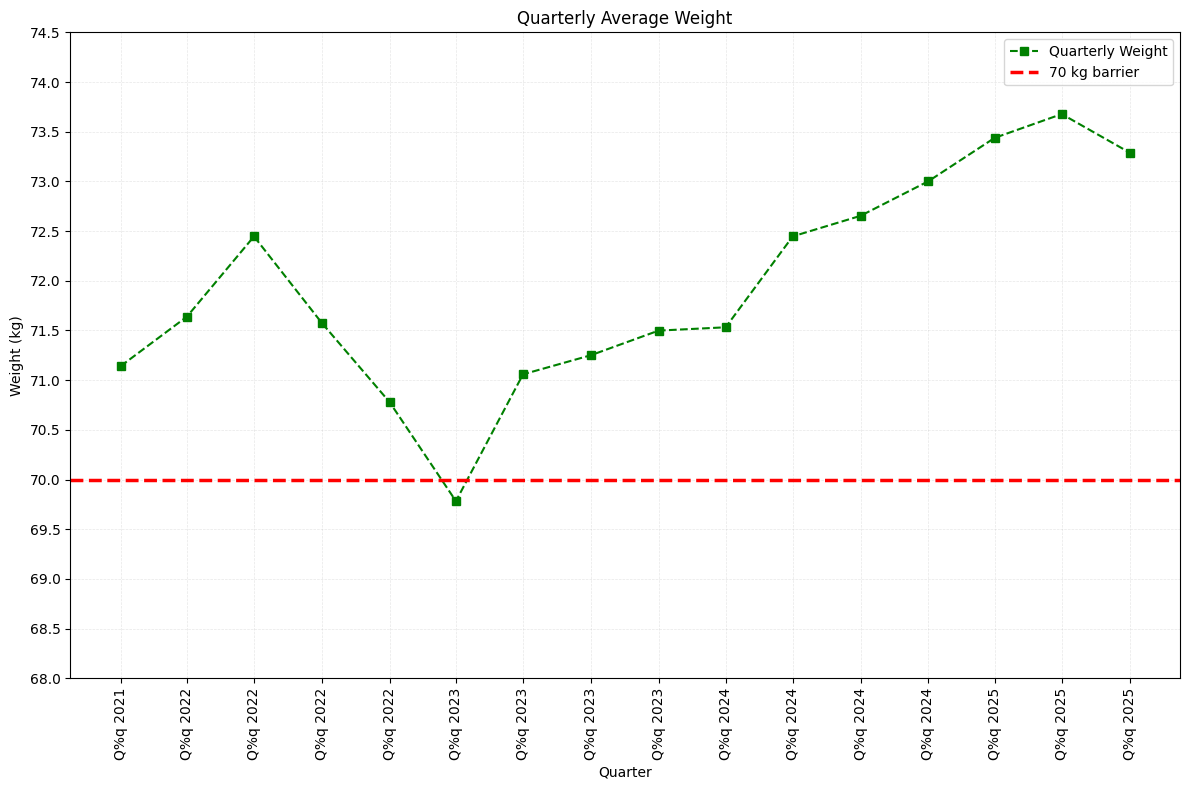

In [16]:
quarterly_df = monthly_df.resample('QE', on='Date').mean()
quarterly_df['Date'] = quarterly_df.index
quarterly_df = quarterly_df.reset_index(drop=True)

dates = quarterly_df['Date']
weights = quarterly_df['Weight']

plt.figure(figsize=(12, 8))
plt.plot(dates, weights, marker='s', linestyle='--', color='green', label='Quarterly Weight')

plt.title('Quarterly Average Weight')
plt.xlabel('Quarter')
plt.ylabel('Weight (kg)')

# Etykiety osi X: wszystkie kwartały, obrócone
plt.xticks(ticks=dates, labels=[d.strftime('Q%q %Y') for d in dates], rotation=90)

# Oś Y: kroki co 0.5 kg
min_weight = weights.min()
max_weight = weights.max()
plt.yticks(np.arange(np.floor(min_weight) - 1, np.ceil(max_weight) + 1, 0.5))

# Pogrubiona linia 70 kg
plt.axhline(y=70, color='red', linestyle='--', linewidth=2.5, label='70 kg barrier')

# Subtelna siatka
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.3)

plt.legend()
plt.tight_layout()
plt.show()


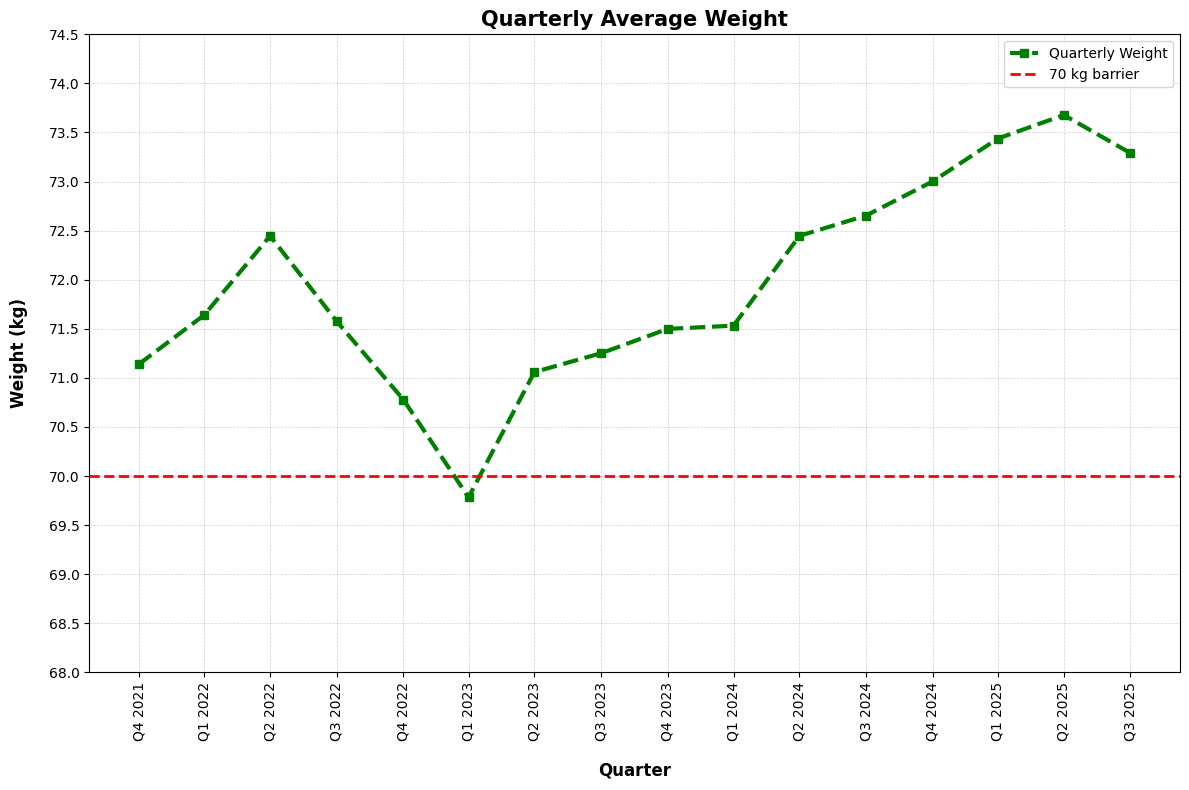

In [17]:
dates = quarterly_df['Date']
weights = quarterly_df['Weight']

plt.figure(figsize=(12, 8))
plt.plot(dates, weights, marker='s', linestyle='--', color='green', linewidth=3, label='Quarterly Weight')

plt.title('Quarterly Average Weight', fontweight='bold', fontsize=15)
plt.xlabel('Quarter', fontsize=12, fontweight='bold', labelpad=15)
plt.ylabel('Weight (kg)', fontsize=12, fontweight='bold', labelpad=15)

# Etykiety osi X: wszystkie kwartały, obrócone
plt.xticks(ticks=dates, labels=[f"Q{((d.month - 1) // 3) + 1} {d.year}" for d in dates], rotation=90)


# Oś Y: kroki co 0.5 kg
min_weight = weights.min()
max_weight = weights.max()
plt.yticks(np.arange(np.floor(min_weight) - 1, np.ceil(max_weight) + 1, 0.5))

# Pogrubiona linia 70 kg
plt.axhline(y=70, color='red', linestyle='--', linewidth=2, label='70 kg barrier')

# Subtelna siatka
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)

plt.legend()
plt.tight_layout()
plt.show()

In [18]:
# Lag features
monthly_df['Weight_t-1'] = monthly_df['Weight'].shift(1)
monthly_df['Weight_t-2'] = monthly_df['Weight'].shift(2)

# Weight change compared to previous month
monthly_df['Delta'] = monthly_df['Weight'] - monthly_df['Weight_t-1']

# Extract month number and year
monthly_df['Month'] = monthly_df['Date'].dt.month
monthly_df['Year'] = monthly_df['Date'].dt.year

# Drop rows with NaN (due to shifting)
monthly_df = monthly_df.dropna().reset_index(drop=True)


In [19]:
monthly_df.head()

,Date,Weight,Weight_t-1,Weight_t-2,Delta,Month,Year
0,2022-02-28,71.592857,71.645161,71.140741,-0.052304,2,2022
1,2022-03-31,71.680645,71.592857,71.645161,0.087788,3,2022
2,2022-04-30,72.540000,71.680645,71.592857,0.859355,4,2022
3,2022-05-31,72.719355,72.540000,71.680645,0.179355,5,2022
4,2022-06-30,72.080000,72.719355,72.540000,-0.639355,6,2022


In [20]:
from sklearn.model_selection import train_test_split

# Features and target
X = monthly_df[['Weight_t-1', 'Weight_t-2', 'Delta', 'Month', 'Year']]
y = monthly_df['Weight']

# Train-test split (bez mieszania kolejności)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


In [21]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.2f} kg")
print(f"RMSE: {rmse:.2f} kg")


MAE: 0.00 kg
RMSE: 0.00 kg


In [24]:
print(X_train.tail())
print(X_test.head())

    Weight_t-1  Weight_t-2     Delta  Month  Year
28   72.470968   72.460000 -0.060968      6  2024
29   72.410000   72.470968  0.115806      7  2024
30   72.525806   72.410000 -0.038710      8  2024
31   72.487097   72.525806  0.461237      9  2024
32   72.948333   72.487097  0.206505     10  2024
    Weight_t-1  Weight_t-2     Delta  Month  Year
33   73.154839   72.948333 -0.604839     11  2024
34   72.550000   73.154839  0.750000     12  2024
35   73.300000   72.550000  0.167742      1  2025
36   73.467742   73.300000 -0.182028      2  2025
37   73.285714   73.467742  0.275576      3  2025


In [25]:
print("Actual values (y_test):")
print(y_test.values)

print("\nPredicted values (y_pred):")
print(y_pred)


Actual values (y_test):
[72.55       73.3        73.46774194 73.28571429 73.56129032 73.56333333
 73.80967742 73.66       73.29032258]

Predicted values (y_pred):
[72.55       73.3        73.46774194 73.28571429 73.56129032 73.56333333
 73.80967742 73.66       73.29032258]


In [26]:
monthly_df[['Weight', 'Weight_t-1']].corr()

,Weight,Weight_t-1
Weight,1.000000,0.892188
Weight_t-1,0.892188,1.000000


MAE: 0.00 kg
RMSE: 0.00 kg
R²: 1.00


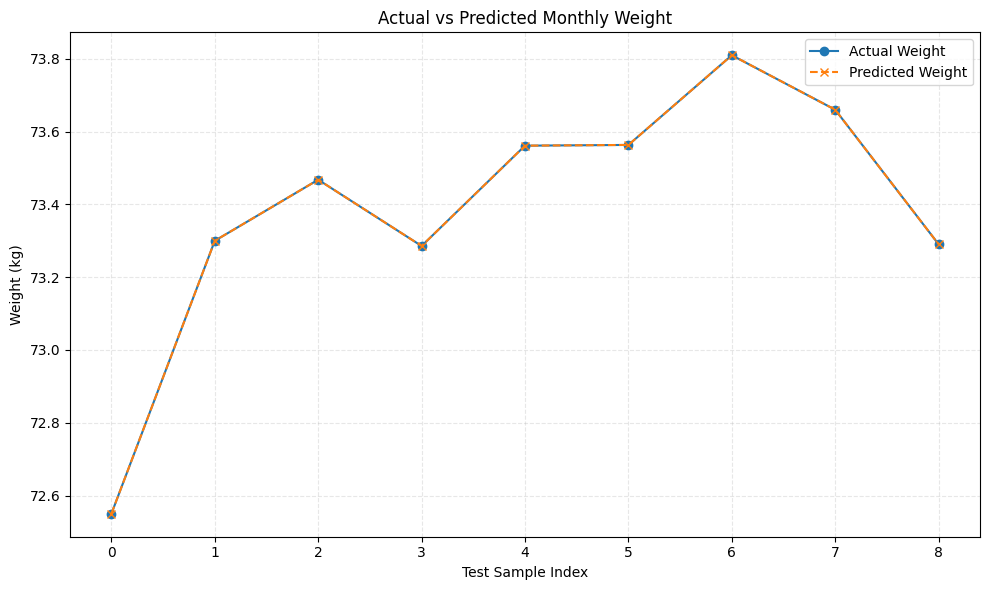

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Zakładam, że monthly_df już istnieje i zawiera odpowiednie kolumny

# Definicja cech i celu
features = ['Weight_t-1', 'Weight_t-2', 'Delta', 'Month', 'Year']
target = 'Weight'

X = monthly_df[features]
y = monthly_df[target]

# Podział na dane treningowe i testowe (bez mieszania kolejności)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Trenowanie modelu
model = LinearRegression()
model.fit(X_train, y_train)

# Predykcja
y_pred = model.predict(X_test)

# Ocena
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f} kg")
print(f"RMSE: {rmse:.2f} kg")
print(f"R²: {r2:.2f}")

# Wykres: rzeczywista vs przewidywana waga
plt.figure(figsize=(10, 6))
plt.plot(y_test.values, label='Actual Weight', marker='o')
plt.plot(y_pred, label='Predicted Weight', marker='x', linestyle='--')
plt.title('Actual vs Predicted Monthly Weight')
plt.xlabel('Test Sample Index')
plt.ylabel('Weight (kg)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
no i znowu skopałeś to: MAE: 0.00 kg
RMSE: 0.00 kg
R²: 1.00. p